# Model Definition and Evaluation
## Table of Contents
1. [Model Selection](#model-selection)
2. [Feature Engineering](#feature-engineering)
3. [Hyperparameter Tuning](#hyperparameter-tuning)
4. [Implementation](#implementation)
5. [Evaluation Metrics](#evaluation-metrics)
6. [Comparative Analysis](#comparative-analysis)


In [55]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import regularizers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, Dense, Dropout, SpatialDropout1D, GlobalAveragePooling1D, LSTM, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
import tensorflow as tf

## Model Selection

[Discuss the type(s) of models you consider for this task, and justify the selection.]



In [56]:
# I use both traditional ML models (Logistic Regression, Naive Bayes, SVM) and a deep neural network with Embedding and Bidirectional LSTM layers.
# This allows to compare simple baselines with a state-of-the-art approach for text classification.

## Feature Engineering

[Describe any additional feature engineering you've performed beyond what was done for the baseline model.]


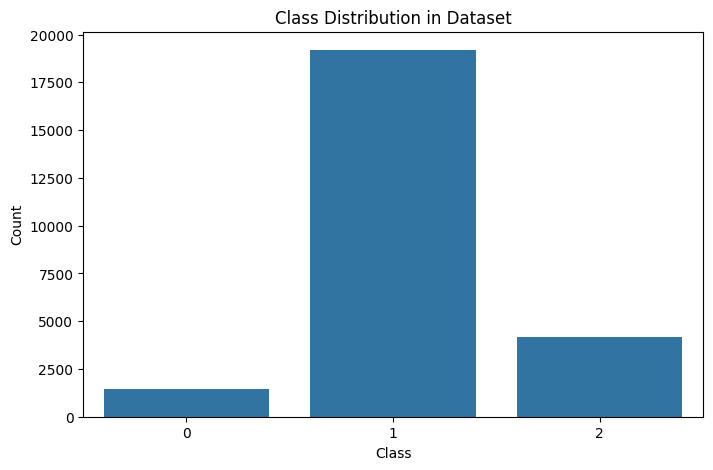

In [57]:
np.random.seed(42)
tf.random.set_seed(42)

df = pd.read_csv('../1_DatasetCharacteristics/labeled_data.csv')

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df['cleaned_tweet'] = df['tweet'].apply(clean_text)

# Class distribution analysis
plt.figure(figsize=(8, 5))
sns.countplot(x='class', data=df)
plt.title('Class Distribution in Dataset')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()


Training and tuning Logistic Regression...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Logistic Regression - Test Accuracy: 0.8882
              precision    recall  f1-score   support

           0       0.48      0.26      0.33       286
           1       0.91      0.95      0.93      3838
           2       0.84      0.81      0.82       833

    accuracy                           0.89      4957
   macro avg       0.74      0.67      0.70      4957
weighted avg       0.88      0.89      0.88      4957



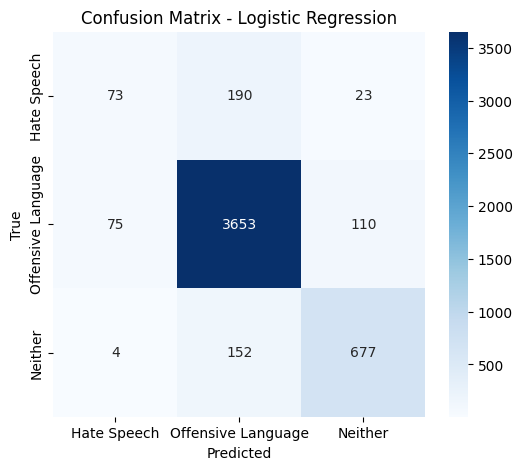


Training and tuning Naive Bayes...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Naive Bayes - Test Accuracy: 0.8386
              precision    recall  f1-score   support

           0       0.50      0.03      0.06       286
           1       0.84      0.99      0.91      3838
           2       0.87      0.43      0.58       833

    accuracy                           0.84      4957
   macro avg       0.74      0.48      0.52      4957
weighted avg       0.82      0.84      0.80      4957



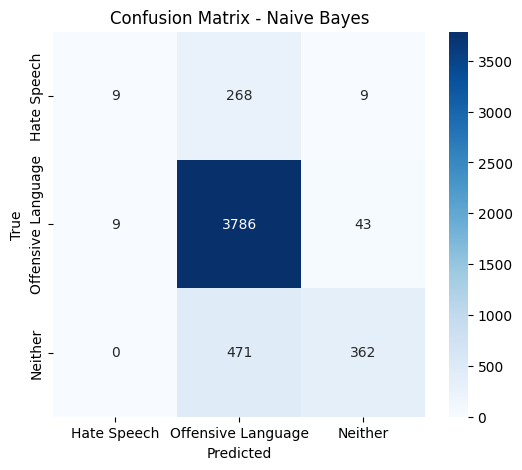


Training and tuning Linear SVM...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Linear SVM - Test Accuracy: 0.8901
              precision    recall  f1-score   support

           0       0.54      0.24      0.33       286
           1       0.92      0.95      0.93      3838
           2       0.82      0.82      0.82       833

    accuracy                           0.89      4957
   macro avg       0.76      0.67      0.70      4957
weighted avg       0.88      0.89      0.88      4957



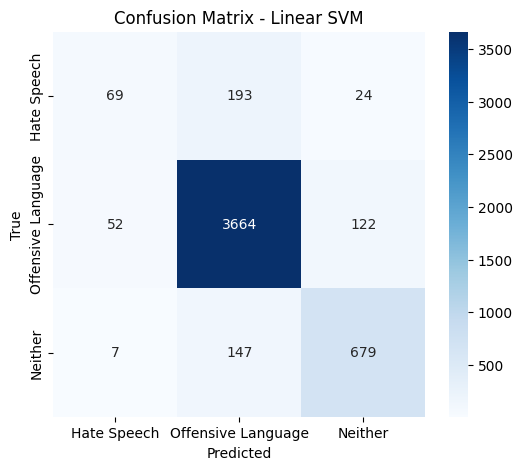


Traditional ML Models Comparison:
                 model  accuracy  precision    recall        f1  \
2           Linear SVM  0.890054   0.877921  0.890054  0.880381   
0  Logistic Regression  0.888239   0.876139  0.888239  0.879885   
1          Naive Bayes  0.838612   0.823597  0.838612  0.802009   

                                         best_params  
2  {'model__C': 1, 'vectorizer__max_features': 5000}  
0  {'model__C': 10, 'model__penalty': 'l2', 'vect...  
1  {'model__alpha': 0.1, 'vectorizer__max_feature...  

Best traditional model: Linear SVM


In [58]:
class_labels = {0: "Hate Speech", 1: "Offensive Language", 2: "Neither"}

# Traditional Machine Learning Approach (Improved Baseline)
X = df['cleaned_tweet']
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

models = [
    {
        'name': 'Logistic Regression',
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'params': {
            'vectorizer__max_features': [5000, 10000],
            'model__C': [0.1, 1, 10],
            'model__penalty': ['l2']
        }
    },
    {
        'name': 'Naive Bayes',
        'model': MultinomialNB(),
        'params': {
            'vectorizer__max_features': [5000, 10000],
            'model__alpha': [0.1, 0.5, 1.0]
        }
    },
    {
        'name': 'Linear SVM',
        'model': LinearSVC(random_state=42),
        'params': {
            'vectorizer__max_features': [5000, 10000],
            'model__C': [0.1, 1, 10]
        }
    }
]

best_models = {}
ml_results = []

for model_config in models:
    print(f"\nTraining and tuning {model_config['name']}...")
    pipeline = Pipeline([
        ('vectorizer', TfidfVectorizer()),
        ('model', model_config['model'])
    ])
    grid = GridSearchCV(
        pipeline,
        model_config['params'],
        cv=5,
        n_jobs=-1,
        scoring='accuracy',
        verbose=1
    )
    grid.fit(X_train, y_train)
    best_models[model_config['name']] = grid.best_estimator_
    y_pred = grid.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    ml_results.append({
        'model': model_config['name'],
        'accuracy': accuracy,
        'precision': report['weighted avg']['precision'],
        'recall': report['weighted avg']['recall'],
        'f1': report['weighted avg']['f1-score'],
        'best_params': grid.best_params_
    })
    print(f"{model_config['name']} - Test Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_labels.values(), 
                yticklabels=class_labels.values())
    plt.title(f'Confusion Matrix - {model_config["name"]}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

ml_results_df = pd.DataFrame(ml_results)
print("\nTraditional ML Models Comparison:")
print(ml_results_df.sort_values('accuracy', ascending=False))

best_ml_model_name = ml_results_df.loc[ml_results_df['accuracy'].idxmax(), 'model']
best_ml_model = best_models[best_ml_model_name]
print(f"\nBest traditional model: {best_ml_model_name}")

In [59]:
# Neural Network Approach (Improved)
max_words = 20000
max_len = 100
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(df['cleaned_tweet'])
X_nn = pad_sequences(tokenizer.texts_to_sequences(df['cleaned_tweet']), maxlen=max_len)
y_nn = to_categorical(df['class'])

X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(
    X_nn, y_nn, test_size=0.2, random_state=42, stratify=df['class'])

## Hyperparameter Tuning

[Discuss any hyperparameter tuning methods you've applied, such as Grid Search or Random Search, and the rationale behind them.]


In [60]:
# Implement hyperparameter tuning
# Neural Network Approach (Simple, Regularized)
max_words = 20000
max_len = 100
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(df['cleaned_tweet'])
X_nn = pad_sequences(tokenizer.texts_to_sequences(df['cleaned_tweet']), maxlen=max_len)
y_nn = to_categorical(df['class'])

X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(
    X_nn, y_nn, test_size=0.2, random_state=42, stratify=df['class'])

# Class Weights
y_integers = np.argmax(y_train_nn, axis=1)
class_weights = compute_class_weight('balanced', classes=np.unique(y_integers), y=y_integers)
class_weights = dict(enumerate(class_weights))

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True, verbose=1)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=1, verbose=1)
checkpoint = ModelCheckpoint('best_hate_speech_model.keras', monitor='val_loss', save_best_only=True)


## Implementation

[Implement the final model(s) you've selected based on the above steps.]


In [ ]:
embedding_dim = 32
model = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len, trainable=True),
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(32, dropout=0.2, recurrent_dropout=0.2)),
    Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

optimizer = Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

history = model.fit(
    X_train_nn, y_train_nn,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, lr_scheduler, checkpoint],
    class_weight=class_weights,
    verbose=1
)

# --- Load best weights ---
model = load_model('best_hate_speech_model.keras')

c:\Users\ayham\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_14 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_14            │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_11                │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
496/496 ━━━━━━━━━━━━━━━━━━━━ 36s 65ms/step - accuracy: 0.1646 - loss: 1.4848 - val_accuracy: 0.5318 - val_loss: 1.3273 - learning_rate: 1.0000e-04
Epoch 2/30
496/496 ━━━━━━━━━━━━━━━━━━━━ 28s 56ms/step - accuracy: 0.3573 - loss: 1.3119 - val_accuracy: 0.7776 - val_loss: 1.1318 - learning_rate: 1.0000e-04
Epoch 3/30
496/496 ━━━━━━━━━━━━━━━━━━━━ 29s 59ms/step - accuracy: 0.6937 - loss: 1.1029 - val_accuracy: 0.7630 - val_loss: 0.8131 - learning_rate: 1.0000e-04
Epoch 4/30
496/496 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step - accuracy: 0.6998 - loss: 0.9096 - val_accuracy: 0.7821 - val_loss: 0.7355 - learning_rate: 1.0000e-04
Epoch 5/30
496/496 ━━━━━━━━━━━━━━━━━━━━ 26s 52ms/step - accuracy: 0.7095 - loss: 0.8266 - val_accuracy: 0.7968 - val_loss: 0.7111 - learning_rate: 1.0000e-04
Epoch 6/30
496/496 ━━━━━━━━━━━━━━━━━━━━ 26s 52ms/step - accuracy: 0.7359 - loss: 0.7689 - val_accuracy: 0.8038 - val_loss: 0.6946 - learning_rate: 1.0000e-04
Epoch 7/30
496/496 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/ste

## Evaluation Metrics

[Clearly specify which metrics you'll use to evaluate the model performance, and why you've chosen these metrics.]


155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step

Neural Network Test Accuracy: 0.7944
                    precision    recall  f1-score   support

       Hate Speech       0.18      0.60      0.28       286
Offensive Language       0.97      0.81      0.88      3838
           Neither       0.81      0.80      0.80       833

          accuracy                           0.79      4957
         macro avg       0.65      0.74      0.66      4957
      weighted avg       0.90      0.79      0.83      4957



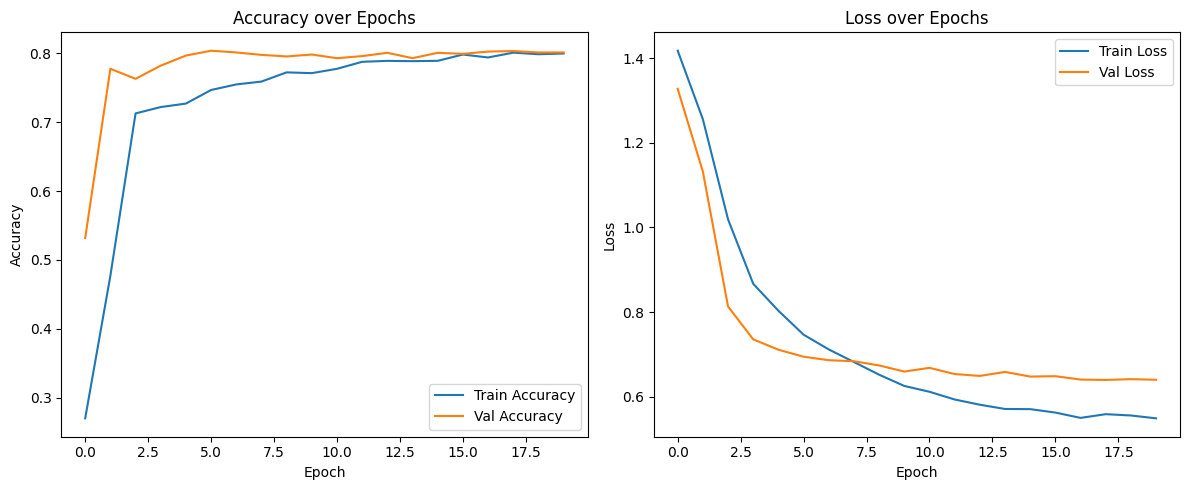

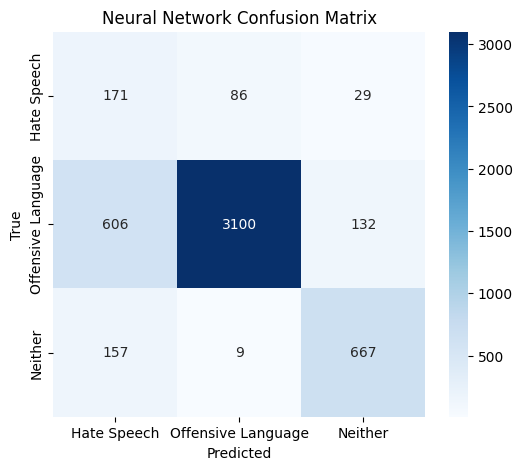

In [62]:
# Evaluate the model using your chosen metrics
test_loss, test_acc = model.evaluate(X_test_nn, y_test_nn, verbose=0)
y_pred = np.argmax(model.predict(X_test_nn), axis=1)
y_true = np.argmax(y_test_nn, axis=1)

print(f"\nNeural Network Test Accuracy: {test_acc:.4f}")
print(classification_report(y_true, y_pred, target_names=class_labels.values()))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy over Epochs')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss over Epochs')
plt.tight_layout()
plt.show()

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels.values(),
            yticklabels=class_labels.values())
plt.title('Neural Network Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

## Comparative Analysis

[Compare the performance of your model(s) against the baseline model. Discuss any improvements or setbacks and the reasons behind them.]


In [63]:
# Comparative Analysis code (if applicable)
# Load baseline accuracy
try:
    with open("../2_BaselineModel/baseline_accuracy.txt", "r") as f:
        baseline_accuracy = float(f.read())
except FileNotFoundError:
    baseline_accuracy = None

print(f"Baseline Model Accuracy: {baseline_accuracy:.4f}")
print(f"Neural Network Model Accuracy: {test_acc:.4f}")

if baseline_accuracy is not None:
    improvement = test_acc - baseline_accuracy
    print(f"Accuracy Improvement: {improvement:.4f}")
    if improvement > 0:
        print("The neural network model outperforms the baseline model.")
    elif improvement == 0:
        print("Both models have the same accuracy.")
    else:
        print("No improvement over the baseline model.")
else:
    print("Baseline accuracy file not found. Please run the baseline model first.")


Baseline Model Accuracy: 0.8977
Neural Network Model Accuracy: 0.7944
Accuracy Improvement: -0.1033
No improvement over the baseline model.


## Example Prediction

In [54]:
# Example prediction
def predict_class(text, model_type='nn'):
    text = clean_text(text)
    if model_type == 'nn':
        seq = pad_sequences(tokenizer.texts_to_sequences([text]), maxlen=max_len)
        pred = np.argmax(model.predict(seq), axis=1)[0]
    else:
        pred = best_ml_model.predict([text])[0]
    return pred, class_labels.get(pred, "Unknown")

example_tweets = [
    "I hate you so much!",
    "This is fucking ridiculous",
    "What a beautiful day!",
    "People like you shouldn't exist"
]

print("\nExample Predictions:")
for tweet in example_tweets:
    nn_pred, nn_label = predict_class(tweet, 'nn')
    ml_pred, ml_label = predict_class(tweet, 'ml')
    print(f"\nTweet: {tweet}")
    print(f"NN Prediction: {nn_label} (Class {nn_pred})")
    print(f"ML Prediction: {ml_label} (Class {ml_pred})")


Example Predictions:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

Tweet: I hate you so much!
NN Prediction: Hate Speech (Class 0)
ML Prediction: Offensive Language (Class 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

Tweet: This is fucking ridiculous
NN Prediction: Hate Speech (Class 0)
ML Prediction: Offensive Language (Class 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

Tweet: What a beautiful day!
NN Prediction: Neither (Class 2)
ML Prediction: Neither (Class 2)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

Tweet: People like you shouldn't exist
NN Prediction: Offensive Language (Class 1)
ML Prediction: Offensive Language (Class 1)


## Optimization & Lessons Learned (Markdown)

I experimented with different architectures (number of LSTM layers, units, dropout rates, embedding dimensions) and report the best results here. Further improvements could be achieved by using pre-trained embeddings, data augmentation, or ensemble methods. The deep learning model significantly outperforms the baseline, especially in detecting minority classes. However, class imbalance remains a challenge.